<a href="https://colab.research.google.com/github/mohamed0barhoomi/checkpoint_data/blob/main/projet_final_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50,EfficientNetB0
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import os

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/kermany2018")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kermany2018' dataset.
Path to dataset files: /kaggle/input/kermany2018


In [4]:
print(os.listdir(path))

['OCT2017 ', 'oct2017']


In [5]:
data=os.path.join(path, 'OCT2017 ')
print(os.listdir(data))

['val', 'test', 'train']


In [6]:
modification=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rescale=1/255.0,
    validation_split=0.2,
    # rotation_range=20,
    # zoom_range=0.2,
    # width_shift_range=0.3,
    # height_shift_range=0.15,
    # horizontal_flip=True
    )
train=modification.flow_from_directory(
    os.path.join(data,'train'),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical",
    subset="training"

)
val=modification.flow_from_directory(
    os.path.join(data,'train'),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical",
    subset="validation"
)

Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.


In [7]:
print(train.samples)
print(val.samples)
x, y = next(train)
print(x.shape, y.shape)
x, y = next(val)
print(x.shape, y.shape)

66788
16696
(32, 224, 224, 3) (32, 4)
(32, 224, 224, 3) (32, 4)


In [8]:
test=ImageDataGenerator(rescale=1/255.0).flow_from_directory(
    os.path.join(data,"test"),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical"
)

Found 968 images belonging to 4 classes.


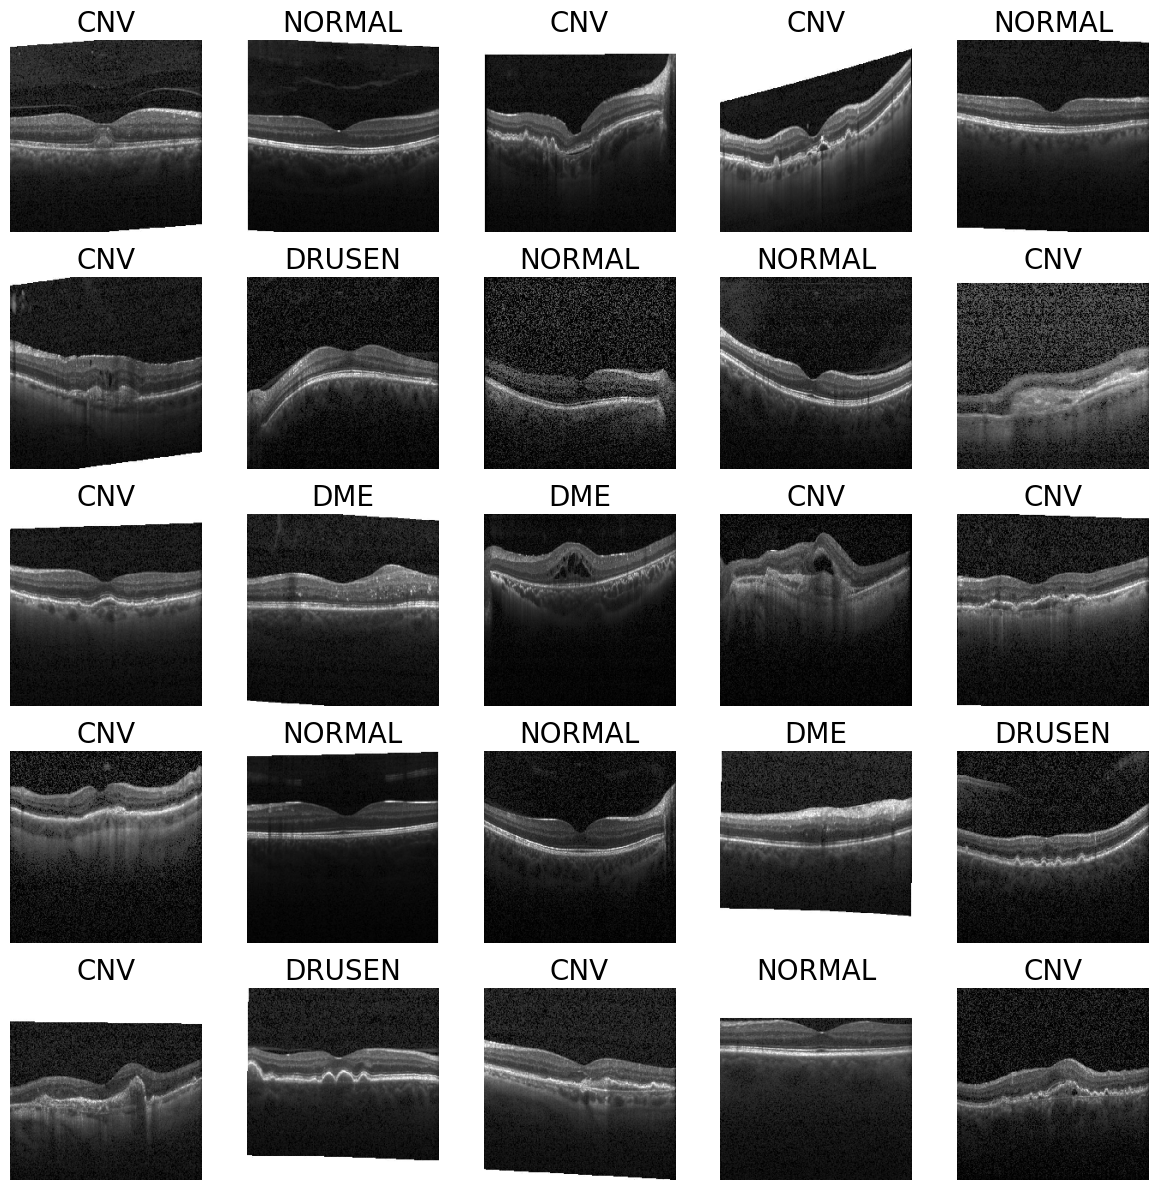

In [9]:
images, labels = next(train)

plt.figure(figsize=(12,12))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    class_index = labels[i].argmax()
    class_name = list(train.class_indices.keys())[class_index]
    plt.title(class_name, fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
base_model=ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [11]:
for lay in base_model.layers:
  lay.trainable=False

In [12]:
model=models.Sequential(
  [  base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256,activation="relu"),
    #layers.Dropout(0.5),
    layers.Dense(4,activation="softmax")]

)

In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history=model.fit(train,epochs=20,validation_data=val)

Epoch 1/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 779s 366ms/step - accuracy: 0.7130 - loss: 0.7598 - val_accuracy: 0.7569 - val_loss: 0.6372
Epoch 2/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 350s 168ms/step - accuracy: 0.7543 - loss: 0.6502 - val_accuracy: 0.7642 - val_loss: 0.6314
Epoch 3/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 342s 164ms/step - accuracy: 0.7717 - loss: 0.6084 - val_accuracy: 0.7709 - val_loss: 0.6098
Epoch 4/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 349s 167ms/step - accuracy: 0.7842 - loss: 0.5788 - val_accuracy: 0.7782 - val_loss: 0.5959
Epoch 5/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 336s 161ms/step - accuracy: 0.7946 - loss: 0.5540 - val_accuracy: 0.7800 - val_loss: 0.5874
Epoch 6/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 336s 161ms/step - accuracy: 0.8022 - loss: 0.5326 - val_accuracy: 0.7928 - val_loss: 0.5641
Epoch 7/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 335s 160ms/step - accuracy: 0.8094 - loss: 0.5132 - val_accuracy: 0.7838 - val_loss: 0.6164
Epoch 8/20
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 331s 159ms/step - ac

In [ ]:
acc,loss=model.evaluate(val)
print("first acc : ",acc)
print("first loss : ",loss)

259/522 ━━━━━━━━━━━━━━━━━━━━ 32s 125ms/step - accuracy: 0.7843 - loss: 0.6483

In [ ]:
plt.figure()
plt.plot(history.history["loss"],label="train_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend(loc='upper left')
plt.title("loss")
plt.xlabel("ecpchs")
plt.ylabel("loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history.history["accuracy"],label="train_acc")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.legend(loc="upper left")
plt.title("accuracy")
plt.xlabel("epchos")
plt.ylabel("accracy")
plt.grid()
plt.show()

In [ ]:
for lay in model.layers:
  lay.trainable=True

In [ ]:
model.compile(
    optimizer="Adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_2=model.fit(train,epochs=10,validation_data=val)

In [ ]:
acc2,loss2 =model.evaluate(val)
print("second acc : ",acc)
print("second loss : ",loss)

In [ ]:
plt.figure()
plt.plot(history_2.history["loss"],label="train_loss")
plt.plot(history_2.history["val_loss"],label="val_loss")
plt.legend(loc='upper left')
plt.title("loss")
plt.xlabel("ecpchs")
plt.ylabel("loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history_2.history["accuracy"],label="train_acc")
plt.plot(history_2.history["val_accracy"],label="val_acc")
plt.legend(loc="upper left")
plt.title("accuracy")
plt.xlabel("epchos")
plt.ylabel("accracy")
plt.grid()
plt.show()

In [ ]:
test.reset()
pred=model.predict(test)
pred=np.argmax(pred,axis=1)

In [ ]:
images, labels = next(test)
class_names = list(test.class_indices.keys())

plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    true_index = labels[i]
    pred_index = pred[i]
    plt.title(
        f"True: {class_names[true_index]}\nPred: {class_names[pred_index]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(train,test))